In [11]:
# Import required libraries
import numpy as np
from typing import Tuple, Union
import atmosphericRadiationDoseAndFlux as ARDF
from atmosphericRadiationDoseAndFlux import particle, particleResponse, units


In [12]:
# Define energy bins array
# Units: MeV (mega-electron volts)
full_energy_bins_array = 10**(0.1*(np.array(range(1,52))-1)+1)  # MeV


In [33]:
full_energy_bins_array

array([1.00000000e+01, 1.25892541e+01, 1.58489319e+01, 1.99526231e+01,
       2.51188643e+01, 3.16227766e+01, 3.98107171e+01, 5.01187234e+01,
       6.30957344e+01, 7.94328235e+01, 1.00000000e+02, 1.25892541e+02,
       1.58489319e+02, 1.99526231e+02, 2.51188643e+02, 3.16227766e+02,
       3.98107171e+02, 5.01187234e+02, 6.30957344e+02, 7.94328235e+02,
       1.00000000e+03, 1.25892541e+03, 1.58489319e+03, 1.99526231e+03,
       2.51188643e+03, 3.16227766e+03, 3.98107171e+03, 5.01187234e+03,
       6.30957344e+03, 7.94328235e+03, 1.00000000e+04, 1.25892541e+04,
       1.58489319e+04, 1.99526231e+04, 2.51188643e+04, 3.16227766e+04,
       3.98107171e+04, 5.01187234e+04, 6.30957344e+04, 7.94328235e+04,
       1.00000000e+05, 1.25892541e+05, 1.58489319e+05, 1.99526231e+05,
       2.51188643e+05, 3.16227766e+05, 3.98107171e+05, 5.01187234e+05,
       6.30957344e+05, 7.94328235e+05, 1.00000000e+06])

In [13]:
def calculate_altitude_layer_params(altitude_meters: float, altitude_km: float) -> Tuple[int, float]:
    """
    Calculate altitude layer index and interpolation factor.
    
    Parameters
    ----------
    altitude_meters : float
        Altitude in meters (m)
    altitude_km : float
        Altitude in kilometers (km)
        
    Returns
    -------
    Tuple[int, float]
        Tuple containing:
        - Altitude layer index (dimensionless)
        - Interpolation factor f1 (dimensionless, 0-1)
        
    Raises
    ------
    Exception
        If altitude is greater than 100 km
    """
    # Check altitude limit (100 km = 100,000 m)
    if altitude_km > 100.0:  # km
        # Can't use exceptions in njit, so return invalid values that will be caught
        return -1, -1.0

    # Altitude thresholds and layer calculations with units
    if altitude_km < 0.025:  # km (25 m)
        layer = 1
        f1 = 1.0  # dimensionless
    elif altitude_km < 1.025:  # km (1025 m)
        layer = int((int(altitude_meters)-25)//50) + 1  # m, 50 m bins
        hr = (int(altitude_meters)-25) % 50  # m remainder
        f1 = 1.0 - hr/50.0  # dimensionless (m/m = 1)
    elif altitude_km < 1.15:  # km (1150 m)
        layer = 21
        f1 = 1.0 - (int(altitude_meters)-1025)/1025.0  # dimensionless (m/m = 1)
    elif altitude_km < 5.05:  # km (5050 m)
        layer = int((int(altitude_meters)-1150)//100) + 22  # m, 100 m bins
        hr = (int(altitude_meters)-1150) % 100  # m remainder
        f1 = 1.0 - hr/100.0  # dimensionless (m/m = 1)
    elif altitude_km < 5.3:  # km
        layer = 61
        f1 = 1.0 - (altitude_km-5.05)/0.25  # dimensionless (km/km = 1)
    elif altitude_km < 15.1:  # km (15100 m)
        layer = int((int(altitude_meters)-5300)//200) + 62  # m, 200 m bins
        hr = (int(altitude_meters)-5300) % 200  # m remainder
        f1 = 1.0 - hr/200.0  # dimensionless (m/m = 1)
    elif altitude_km < 16.5:  # km
        layer = 111
        f1 = 1.0 - (altitude_km-15.1)/1.4  # dimensionless (km/km = 1)
    elif altitude_km < 38.5:  # km (38500 m)
        layer = int((int(altitude_meters)-16500)//1000) + 112  # m, 1000 m bins
        hr = (int(altitude_meters)-16500) % 1000  # m remainder
        f1 = 1.0 - hr/1000.0  # dimensionless (m/m = 1)
    elif altitude_km < 40.5:  # km
        layer = 134
        f1 = 1.0 - (altitude_km-38.5)/2.0  # dimensionless (km/km = 1)
    elif altitude_km < 62.5:  # km
        layer = 135
        f1 = 1.0 - (altitude_km-40.5)/22.0  # dimensionless (km/km = 1)
    elif altitude_km < 97.5:  # km
        layer = 136
        f1 = 1.0 - (altitude_km-40.5)/57.5  # dimensionless (km/km = 1)
    else:
        layer = 137
        f1 = 1.0  # dimensionless

    # Convert from 1-indexed to 0-indexed for Python arrays
    altitude_layer_index = layer - 1  # dimensionless index
    
    return altitude_layer_index, f1


In [14]:
def getAltitudeResponseLayer(altitude):
    """
    Calculate altitude response layer and interpolation factor.
    
    Parameters
    ----------
    altitude : Distance
        Altitude object with .meters (m) and .km (km) attributes
        
    Returns
    -------
    Tuple[int, float]
        Tuple containing:
        - Altitude layer index (dimensionless)
        - Interpolation factor f1 (dimensionless, 0-1)
        
    Raises
    ------
    Exception
        If altitude is greater than 100 km
    """
    # Use function for layer calculation
    # Input: altitude.meters (m), altitude.km (km)
    # Output: altitude_layer_index (dimensionless), f1 (dimensionless)
    altitude_layer_index, f1 = calculate_altitude_layer_params(
        altitude.meters, altitude.km  # m, km
    )
    
    # Check for error from function (altitude > 100 km)
    if altitude_layer_index == -1:
        raise Exception("altitude.km has to be less than 100 km!")

    return altitude_layer_index, f1  # dimensionless, dimensionless


In [15]:
def get_energy_index_from_energy_MeV(energy_MeV: float) -> int:
    """
    Get the energy index corresponding to a given energy in MeV.
    
    Parameters
    ----------
    energy_MeV : float
        Energy in MeV (mega-electron volts)
        
    Returns
    -------
    int
        Index of the closest energy bin (dimensionless)
    """
    # Find closest energy bin: |full_energy_bins_array (MeV) - energy_MeV (MeV)|
    # Returns dimensionless index
    return np.argmin(np.abs(full_energy_bins_array - energy_MeV))  # MeV - MeV = MeV, index is dimensionless


In [16]:
def dose_response_term(response_values: np.ndarray, 
                       alt_index: int, 
                       alt_index_above: int, 
                       energy_idx: int, 
                       f1: float) -> float:
    """
    Compute the difference between the interpolated response terms for a given energy bin.
    
    Parameters
    ----------
    response_values : np.ndarray
        Array of response values with units dependent on dose type:
        - For edose: µSv⋅cm²⋅hr⁻¹⋅particle⁻¹ (microSievert⋅cm²⋅hr⁻¹⋅particle⁻¹)
    alt_index : int
        Index for altitude layer (dimensionless)
    alt_index_above : int
        Index for altitude layer above (dimensionless)
    energy_idx : int
        Index for energy bin (dimensionless)
    f1 : float
        Interpolation factor (dimensionless, 0-1)
        
    Returns
    -------
    float
        Interpolated dose response term (same units as response_values)
        For edose: µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
    """
    # Linear interpolation between altitude layers
    # first_term: response_values[µSv⋅cm²⋅hr⁻¹⋅particle⁻¹] * f1[dimensionless] = µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
    first_term = response_values[alt_index, energy_idx] * f1
    # second_term: response_values[µSv⋅cm²⋅hr⁻¹⋅particle⁻¹] * (f1-1)[dimensionless] = µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
    second_term = response_values[alt_index_above, energy_idx] * (f1 - 1)
    # Result: µSv⋅cm²⋅hr⁻¹⋅particle⁻¹ - µSv⋅cm²⋅hr⁻¹⋅particle⁻¹ = µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
    return first_term - second_term


In [17]:
def full_calculate_response_terms(energy_in_MeV=1000, altitude_in_km=12.192):
    """
    Calculate dose response terms for a given energy and altitude.
    
    Parameters
    ----------
    energy_in_MeV : float, optional
        Energy in MeV (mega-electron volts) (default: 1000 MeV)
    altitude_in_km : float, optional
        Altitude in kilometers (km) (default: 12.192 km)
        
    Returns
    -------
    float
        Calculated dose response term for edose in µSv⋅cm²⋅hr⁻¹⋅particle⁻¹ (microSievert⋅cm²⋅hr⁻¹⋅particle⁻¹)
    """
    from atmosphericRadiationDoseAndFlux import particle, particleResponse, units

    # Set up particle and dose type
    particleForCalculations = particle.Particle("proton")  # Proton particles
    doseType = "edose"  # Effective dose

    # Get dose response object for proton edose
    doseResponseForParticle = particleResponse.fullDoseResponseDict[doseType](particleForCalculations, doseType)

    # Convert altitude: km -> m for Distance object
    altitude = units.Distance(altitude_in_km * 1000.0)  # km * 1000 = m

    # Load response array from file
    # Units: µSv⋅cm²⋅hr⁻¹⋅particle⁻¹ (microSievert⋅cm²⋅hr⁻¹⋅particle⁻¹)
    particleResponseArray = np.genfromtxt(doseResponseForParticle.getPathToResponseFile())
    
    # Get altitude interpolation parameters
    # Returns: altIndex (dimensionless), f1 (dimensionless)
    altIndex, f1 = getAltitudeResponseLayer(altitude)  # m -> dimensionless, dimensionless
    altIndexAbove = altIndex + 1  # dimensionless

    # Get energy bin index
    # Returns: energy_idx (dimensionless)
    energy_idx = get_energy_index_from_energy_MeV(energy_in_MeV)  # MeV -> dimensionless

    # Calculate interpolated dose response term
    # Returns: µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
    return dose_response_term(response_values=particleResponseArray,  # µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
                        alt_index=altIndex,        # dimensionless
                        alt_index_above=altIndexAbove,  # dimensionless
                        energy_idx=energy_idx,     # dimensionless
                        f1=f1)                     # dimensionless
    # Final result: µSv⋅cm²⋅hr⁻¹⋅particle⁻¹


In [18]:
# Example usage
# Input: 1000 MeV proton energy, 12.192 km altitude
# Output: Effective dose response term in µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
result = full_calculate_response_terms(energy_in_MeV=1000, altitude_in_km=12.192)  # MeV, km
print(f"Dose response term: {result} µSv⋅cm²⋅hr⁻¹⋅particle⁻¹")  # µSv⋅cm²⋅hr⁻¹⋅particle⁻¹


Dose response term: 3.3212 µSv⋅cm²⋅hr⁻¹⋅particle⁻¹


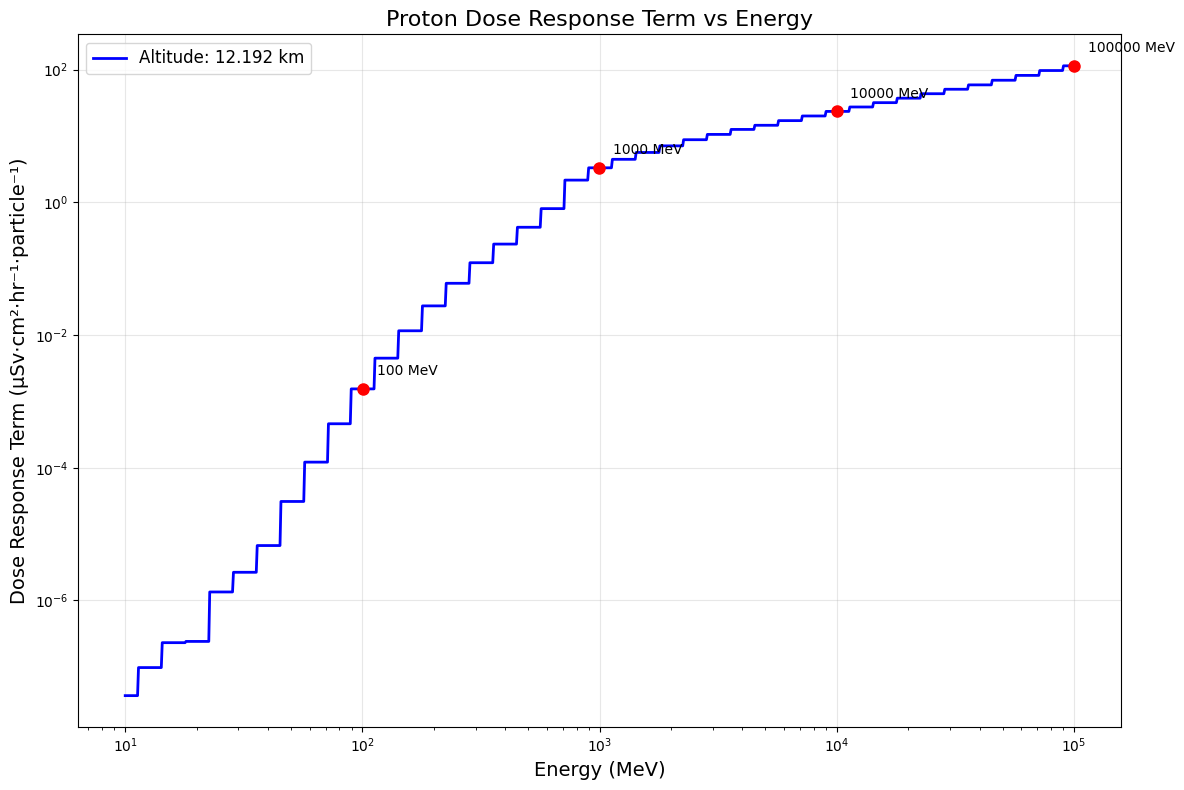


Dose response terms at key energies (altitude: 12.192 km):
   100 MeV:     0.00 µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
  1000 MeV:     3.32 µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
 10000 MeV:    23.51 µSv⋅cm²⋅hr⁻¹⋅particle⁻¹
100000 MeV:   114.38 µSv⋅cm²⋅hr⁻¹⋅particle⁻¹


In [19]:
# Plot dose response term across full energy range
import matplotlib.pyplot as plt

# Define energy range (MeV) - using the full range from the energy bins
energy_range = np.logspace(1, 5, 1000)  # 10 MeV to 100,000 MeV, 1000 points
altitude = 12.192  # km

# Calculate dose response terms for each energy
dose_response_terms = []
for energy in energy_range:
    response = full_calculate_response_terms(energy_in_MeV=energy, altitude_in_km=altitude)
    dose_response_terms.append(response)

# Create the plot
plt.figure(figsize=(12, 8))
plt.loglog(energy_range, dose_response_terms, 'b-', linewidth=2, label=f'Altitude: {altitude} km')

plt.xlabel('Energy (MeV)', fontsize=14)
plt.ylabel('Dose Response Term (µSv⋅cm²⋅hr⁻¹⋅particle⁻¹)', fontsize=14)
plt.title('Proton Dose Response Term vs Energy', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add some key energy points for reference
key_energies = [100, 1000, 10000, 100000]  # MeV
for energy in key_energies:
    if energy <= energy_range[-1]:
        idx = np.argmin(np.abs(energy_range - energy))
        plt.plot(energy_range[idx], dose_response_terms[idx], 'ro', markersize=8)
        plt.annotate(f'{energy} MeV', 
                    xy=(energy_range[idx], dose_response_terms[idx]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, ha='left')

plt.tight_layout()
plt.show()

# Print some key values
print(f"\nDose response terms at key energies (altitude: {altitude} km):")
for energy in key_energies:
    if energy <= energy_range[-1]:
        idx = np.argmin(np.abs(energy_range - energy))
        print(f"{energy:6d} MeV: {dose_response_terms[idx]:8.2f} µSv⋅cm²⋅hr⁻¹⋅particle⁻¹")


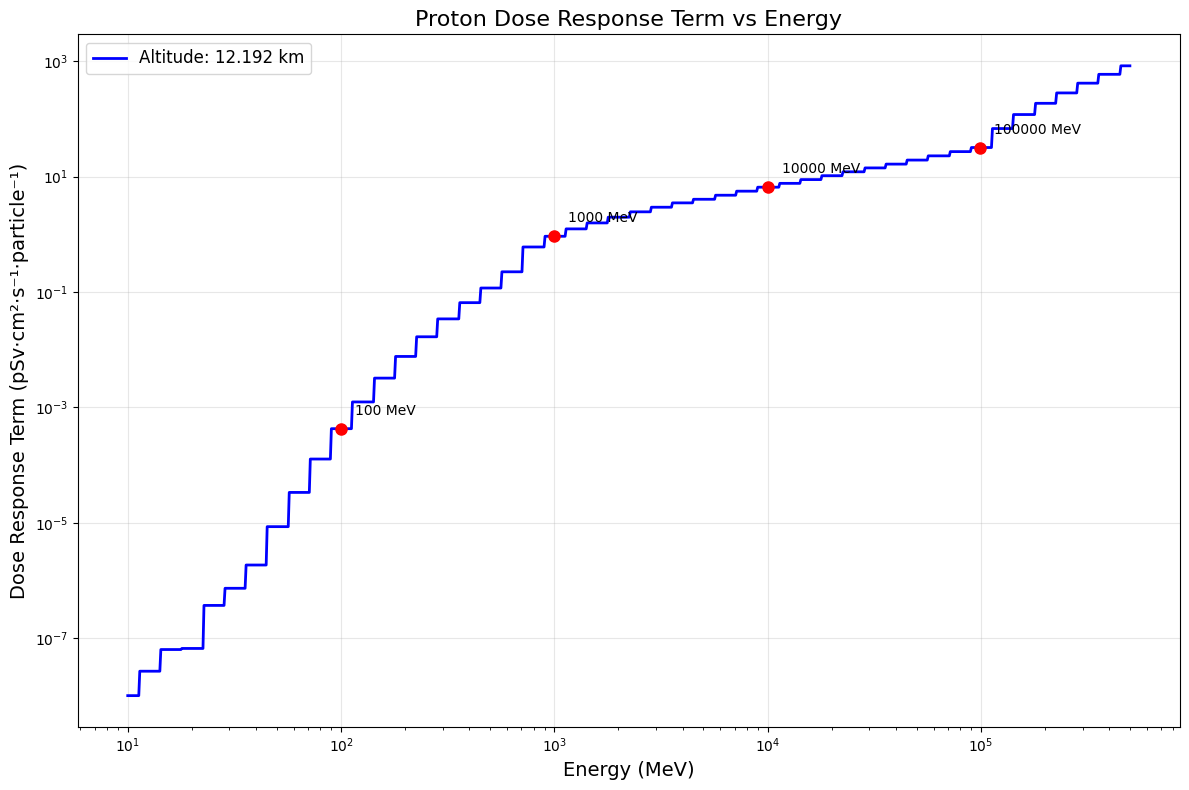


Dose response terms at key energies (altitude: 12.192 km):
   100 MeV:     0.00 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
  1000 MeV:     0.92 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
 10000 MeV:     6.53 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
100000 MeV:    31.77 pSv⋅cm²⋅s⁻¹⋅particle⁻¹


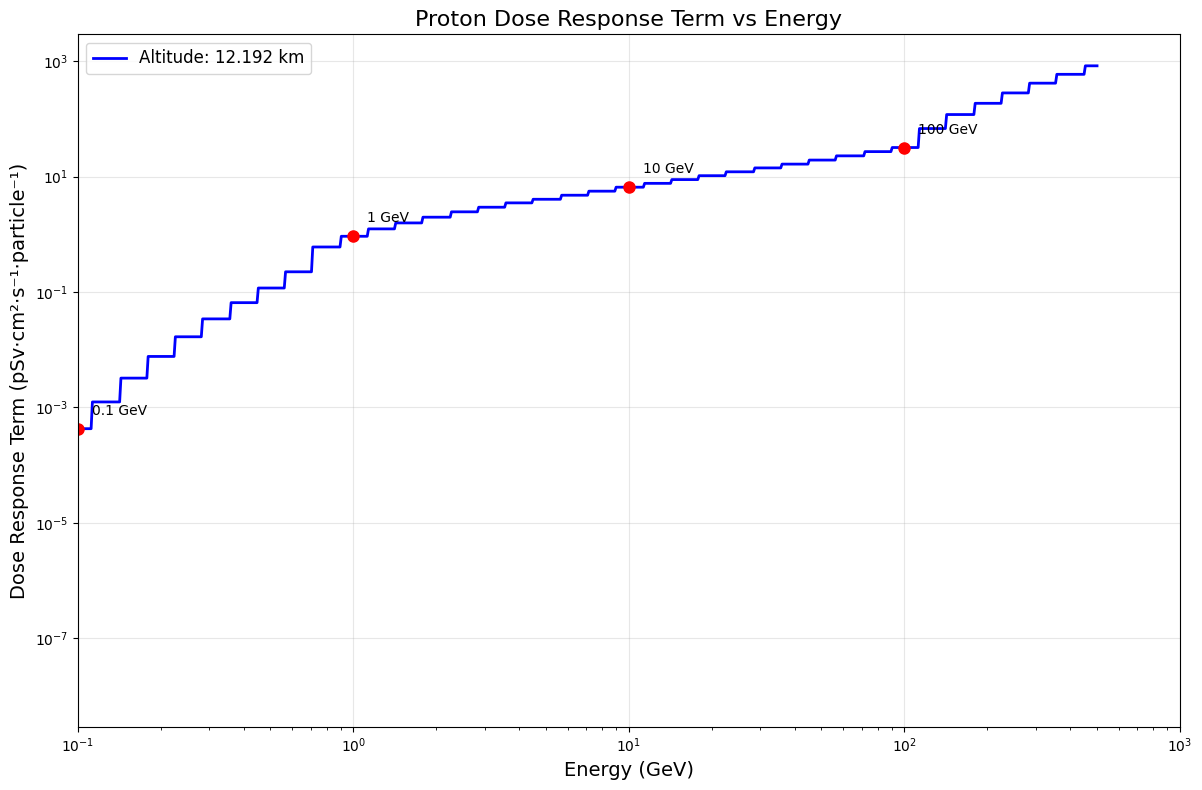


Dose response terms at key energies (altitude: 12.192 km):
  0.1 GeV:     0.00 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
  1.0 GeV:     0.92 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
 10.0 GeV:     6.53 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
100.0 GeV:    31.77 pSv⋅cm²⋅s⁻¹⋅particle⁻¹


In [40]:
# Plot dose response term across full energy range in pSv⋅cm²⋅s⁻¹⋅particle⁻¹
import matplotlib.pyplot as plt

# Define energy range (MeV) - using the full range from the energy bins
energy_range = np.geomspace(10, 0.5e6, 1000)  # 10 MeV to 1,000,000 MeV (1000 GeV), 1000 points
altitude = 12.192  # km

# Calculate dose response terms for each energy
dose_response_terms = []
for energy in energy_range:
    response = full_calculate_response_terms(energy_in_MeV=energy, altitude_in_km=altitude)
    dose_response_terms.append(response)

# Convert from µSv⋅cm²⋅hr⁻¹⋅particle⁻¹ to pSv⋅cm²⋅s⁻¹⋅particle⁻¹
# 1 µSv = 1000 pSv, 1 hr = 3600 s
conversion_factor = 1000 / 3600  # Convert µSv/hr to pSv/s
dose_response_terms_pSv = [term * conversion_factor for term in dose_response_terms]

# Create the plot
plt.figure(figsize=(12, 8))
plt.loglog(energy_range, dose_response_terms_pSv, 'b-', linewidth=2, label=f'Altitude: {altitude} km')

plt.xlabel('Energy (MeV)', fontsize=14)
plt.ylabel('Dose Response Term (pSv⋅cm²⋅s⁻¹⋅particle⁻¹)', fontsize=14)
plt.title('Proton Dose Response Term vs Energy', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add some key energy points for reference
key_energies = [100, 1000, 10000, 100000]  # MeV
for energy in key_energies:
    if energy <= energy_range[-1]:
        idx = np.argmin(np.abs(energy_range - energy))
        plt.plot(energy_range[idx], dose_response_terms_pSv[idx], 'ro', markersize=8)
        plt.annotate(f'{energy} MeV', 
                    xy=(energy_range[idx], dose_response_terms_pSv[idx]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, ha='left')

plt.tight_layout()
plt.show()

# Print some key values
print(f"\nDose response terms at key energies (altitude: {altitude} km):")
for energy in key_energies:
    if energy <= energy_range[-1]:
        idx = np.argmin(np.abs(energy_range - energy))
        print(f"{energy:6d} MeV: {dose_response_terms_pSv[idx]:8.2f} pSv⋅cm²⋅s⁻¹⋅particle⁻¹")

# Create a second plot with energy in GeV
plt.figure(figsize=(12, 8))
energy_range_GeV = energy_range / 1000  # Convert MeV to GeV
plt.loglog(energy_range_GeV, dose_response_terms_pSv, 'b-', linewidth=2, label=f'Altitude: {altitude} km')

plt.xlabel('Energy (GeV)', fontsize=14)
plt.ylabel('Dose Response Term (pSv⋅cm²⋅s⁻¹⋅particle⁻¹)', fontsize=14)
plt.title('Proton Dose Response Term vs Energy', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add some key energy points for reference in GeV
key_energies_GeV = [0.1, 1, 10, 100]  # GeV
for energy_GeV in key_energies_GeV:
    if energy_GeV <= energy_range_GeV[-1]:
        idx = np.argmin(np.abs(energy_range_GeV - energy_GeV))
        plt.plot(energy_range_GeV[idx], dose_response_terms_pSv[idx], 'ro', markersize=8)
        plt.annotate(f'{energy_GeV} GeV', 
                    xy=(energy_range_GeV[idx], dose_response_terms_pSv[idx]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, ha='left')

plt.tight_layout()
plt.xlim(1e-1, 1000)
plt.show()

# Print some key values in GeV
print(f"\nDose response terms at key energies (altitude: {altitude} km):")
for energy_GeV in key_energies_GeV:
    if energy_GeV <= energy_range_GeV[-1]:
        idx = np.argmin(np.abs(energy_range_GeV - energy_GeV))
        print(f"{energy_GeV:5.1f} GeV: {dose_response_terms_pSv[idx]:8.2f} pSv⋅cm²⋅s⁻¹⋅particle⁻¹")


In [ ]:
# 0      0.1            0.0079      0.000200
# 1      0.3            0.1680      0.004255
# 2      0.5            5.5000      0.139317
# 3      1.0           61.5000      1.557813
# 4      2.0          132.0000      3.343599
# 5      3.0          147.0000      3.723553
# 6      4.0          260.0000      6.585877
# 7      5.0          336.0000      8.510979
# 8      6.0          405.0000     10.258770
# 9      7.0          460.0000     11.651936
# 10     8.0          535.0000     13.551708
# 11     9.0          582.0000     14.742232
# 12    10.0          638.0000     16.160729
# 13    15.0          906.0000     22.949248
# 14    20.0         1190.0000     30.143052
# 15    30.0         1680.0000     42.554897
# 16    50.0         2680.0000     67.885193
# 17    70.0         3680.0000     93.215489
# 18   100.0         5480.0000    138.810022
# 19   300.0        16300.0000    412.883823
# 20   500.0        27000.0000    683.917990
# 21   700.0        38100.0000    965.084274
# 22  1000.0        57000.0000   1443.826867

In [42]:
import pandas as pd

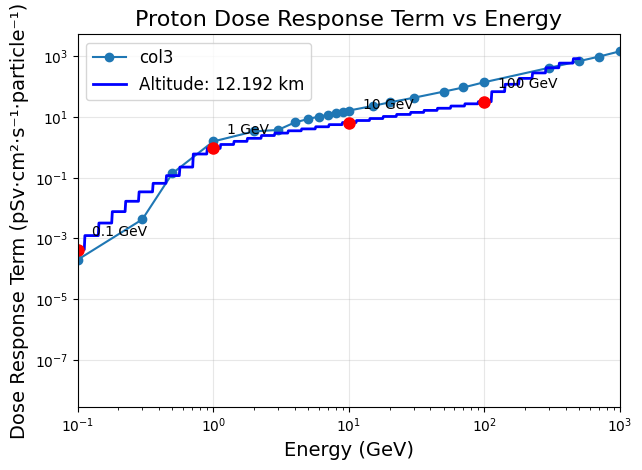

In [47]:
# Create DataFrame from the table data
data = {
    'index': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22],
    'col1': [0.1, 0.3, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 15.0, 20.0, 30.0, 50.0, 70.0, 100.0, 300.0, 500.0, 700.0, 1000.0],
    'col2': [0.0079, 0.1680, 5.5000, 61.5000, 132.0000, 147.0000, 260.0000, 336.0000, 405.0000, 460.0000, 535.0000, 582.0000, 638.0000, 906.0000, 1190.0000, 1680.0000, 2680.0000, 3680.0000, 5480.0000, 16300.0000, 27000.0000, 38100.0000, 57000.0000],
    'col3': [0.000200, 0.004255, 0.139317, 1.557813, 3.343599, 3.723553, 6.585877, 8.510979, 10.258770, 11.651936, 13.551708, 14.742232, 16.160729, 22.949248, 30.143052, 42.554897, 67.885193, 93.215489, 138.810022, 412.883823, 683.917990, 965.084274, 1443.826867]
}

df = pd.DataFrame(data)
df.set_index('index', inplace=True)

df.plot('col1','col3',marker='o')

energy_range_GeV = energy_range / 1000  # Convert MeV to GeV
plt.loglog(energy_range_GeV, dose_response_terms_pSv, 'b-', linewidth=2, label=f'Altitude: {altitude} km')

plt.xlabel('Energy (GeV)', fontsize=14)
plt.ylabel('Dose Response Term (pSv⋅cm²⋅s⁻¹⋅particle⁻¹)', fontsize=14)
plt.title('Proton Dose Response Term vs Energy', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add some key energy points for reference in GeV
key_energies_GeV = [0.1, 1, 10, 100]  # GeV
for energy_GeV in key_energies_GeV:
    if energy_GeV <= energy_range_GeV[-1]:
        idx = np.argmin(np.abs(energy_range_GeV - energy_GeV))
        plt.plot(energy_range_GeV[idx], dose_response_terms_pSv[idx], 'ro', markersize=8)
        plt.annotate(f'{energy_GeV} GeV', 
                    xy=(energy_range_GeV[idx], dose_response_terms_pSv[idx]),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, ha='left')

plt.tight_layout()
plt.xlim(1e-1, 1000)
plt.show()

In [39]:
# Print dose response terms for specific energies
specific_energies = [100, 200, 300, 500, 1000, 2000, 4000, 8000, 10000, 20000, 50000, 100000]  # MeV (0.1, 0.2, 0.5, 1, 2, 4, 8, 10, 20, 50, 100 GeV)
print(f"\nDose response terms at specific energies (altitude: {altitude} km):")
for energy in specific_energies:
    response = full_calculate_response_terms(energy_in_MeV=energy, altitude_in_km=altitude)
    response_pSv = response * conversion_factor
    print(f"{energy/1000:4.2f} GeV ({energy:5d} MeV): {response_pSv:8.2f} pSv⋅cm²⋅s⁻¹⋅particle⁻¹")



Dose response terms at specific energies (altitude: 12.192 km):
0.10 GeV (  100 MeV):     0.00 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
0.20 GeV (  200 MeV):     0.01 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
0.30 GeV (  300 MeV):     0.03 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
0.50 GeV (  500 MeV):     0.12 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
1.00 GeV ( 1000 MeV):     0.92 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
2.00 GeV ( 2000 MeV):     1.98 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
4.00 GeV ( 4000 MeV):     3.50 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
8.00 GeV ( 8000 MeV):     5.57 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
10.00 GeV (10000 MeV):     6.53 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
20.00 GeV (20000 MeV):    10.34 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
50.00 GeV (50000 MeV):    19.27 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
100.00 GeV (100000 MeV):    31.77 pSv⋅cm²⋅s⁻¹⋅particle⁻¹
